# Cell types by region — AI vs Otsu positivity, across every project

Each imaged region was gated twice from the same segmentation and the same gate
definitions, differing only in how marker positivity was called: **Otsu** thresholding
or the **AI** model from `CellMarkerPositivity`. Every project therefore comes as an
`…_Otsu.zarr` / `…_AI.zarr` pair.

For each pair this notebook counts how many cells of each type fall in the **Lesion** and
**Lung** regions, then scores how cleanly each cell type separates the two regions with
**Fisher's linear discriminant**. Results are reported **for each sample separately**
(`20231208` and `20231214`) and as a mean over the two.

Two details that matter for reading the numbers:

* **Cells, not pixels.** Type masks are pixel masks, so they are turned back into cells
  through the segmentation label map: a cell belongs to a type when at least
  `MEMBERSHIP_FRAC` of its pixels are covered, and its region comes from its centroid.
* **Regions are drawn as several polygons.** A project may carry `Lesion 1`, `Lesion 2`,
  `Lesion 3`, `Lung 1`, `Lung 2`. These are grouped by their leading word, so every
  lesion polygon counts as Lesion and every lung polygon as Lung.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:/opal-studio/Projects")

# Cases to leave out, matched as a substring of the project name.
EXCLUDE = ["20231214_714Lung_E_3_20231214-153352-220044_Q004"]

METHODS = ["Otsu", "AI"]            # order used everywhere: tables, bars, legends
SEGMENTATION = "StarDist_Expand"    # mask channel holding the cell label map
REGIONS = ["Lesion", "Lung"]        # region groups, by leading word of the channel name
POSITIVE_REGION = "Lesion"          # where tumour types are expected

MEMBERSHIP_FRAC = 0.5     # a cell joins a type when this fraction of it is covered
DROP_TYPES = ["Unknown"]  # not a real cell type; excluded from the averages
TUMOUR_PATTERNS = ["tumor", "tumour"]   # substring match, case-insensitive

# Shown on its own beside the all-types average in the headline table.
FOCUS_TYPE = "Tumor epithelial cells"

OPAL_STUDIO_REPO = Path(r"C:/opal-studio")

## Which projects are being compared

In [2]:
import json
import re
import sys
from collections import Counter

import numpy as np
import pandas as pd

if str(OPAL_STUDIO_REPO) not in sys.path:
    sys.path.insert(0, str(OPAL_STUDIO_REPO))

from opal_studio import project_io
from scipy import ndimage
from skimage.draw import polygon as draw_polygon


def discover_pairs(root, exclude=()):
    '''Find every project that exists for all of METHODS.

    A project is <stem>_<method>.zarr; the sample is the leading date field of the
    stem and the case its trailing field, which is what results are grouped by.
    '''
    found = {}
    pattern = re.compile(r"^(.*)_(" + "|".join(METHODS) + r")\.zarr$")
    for path in sorted(Path(root).iterdir()):
        m = pattern.match(path.name)
        if not m or not (path / "zarr.json").exists():
            continue
        stem, method = m.group(1), m.group(2)
        if any(x in stem for x in exclude):
            continue
        found.setdefault(stem, {})[method] = path

    pairs = []
    for stem, by_method in sorted(found.items()):
        missing = [m for m in METHODS if m not in by_method]
        if missing:
            print(f"skipping {stem}: no {', '.join(missing)} project")
            continue
        pairs.append({"stem": stem, "sample": stem.split("_")[0],
                      "case": stem.split("_")[-1],
                      "stores": {m: by_method[m] for m in METHODS}})
    return pairs


projects = discover_pairs(PROJECT_ROOT, EXCLUDE)
SAMPLES = sorted({p["sample"] for p in projects})

print(f"{len(projects)} project pairs over {len(SAMPLES)} samples "
      f"{dict(Counter(p['sample'] for p in projects))}")
if EXCLUDE:
    print(f"excluded: {', '.join(EXCLUDE)}")
display(pd.DataFrame([{"sample": p["sample"], "case": p["case"], "stem": p["stem"]}
                      for p in projects]))

11 project pairs over 2 samples {'20231208': 4, '20231214': 7}
excluded: 20231214_714Lung_E_3_20231214-153352-220044_Q004


,sample,case,stem
0,20231208,Q001,20231208_712Lung_T_20231208-162603-634659_Q001
1,20231208,Q002,20231208_712Lung_T_20231208-162603-634659_Q002
2,20231208,Q003,20231208_712Lung_T_20231208-162603-634659_Q003
3,20231208,Q004,20231208_712Lung_T_20231208-162603-634659_Q004
4,20231214,Q001,20231214_714Lung_E_3_20231214-153352-220044_Q001
5,20231214,Q002,20231214_714Lung_E_3_20231214-153352-220044_Q002
6,20231214,Q003,20231214_714Lung_E_3_20231214-153352-220044_Q003
7,20231214,Q005,20231214_714Lung_E_3_20231214-153352-220044_Q005
8,20231214,Q006,20231214_714Lung_E_3_20231214-153352-220044_Q006
9,20231214,Q007,20231214_714Lung_E_3_20231214-153352-220044_Q007


## Reading a project

Only the elements this analysis needs are read — the segmentation and the type masks —
rather than the whole store, which also holds a positivity mask per marker and would be
far slower and heavier to load.

In [3]:
def read_session(store):
    '''The Opal Studio session block: the channel list and what kind each channel is.'''
    meta = json.loads((Path(store) / "zarr.json").read_text())
    return meta["attributes"]["opal_studio"]["session"]


def channels_of_kind(session, kind):
    return [c["name"] for c in session["channels"] if c.get("kind") == kind]


def load_elements(store, want_labels):
    '''Read just the named label rasters, plus every region polygon.'''
    store = Path(store)
    labels, shapes = {}, {}

    label_dir = store / "labels"
    if label_dir.is_dir():
        for elem in sorted(label_dir.iterdir()):
            if not (elem / "0" / "zarr.json").exists():
                continue
            key = project_io._read_element_key(elem / "zarr.json", elem.name)
            if key in want_labels:
                arr = project_io._read_v3_array(elem / "0")
                labels[key] = arr[0] if arr.ndim == 3 else arr

    shape_dir = store / "shapes"
    if shape_dir.is_dir():
        for elem in sorted(shape_dir.iterdir()):
            if not (elem / "shapes.parquet").exists():
                continue
            key = project_io._read_element_key(elem / "zarr.json", elem.name)
            shapes[key] = project_io._read_shapes_parquet(elem / "shapes.parquet")

    return labels, shapes


def region_group(name):
    '''"Lesion 2" -> "Lesion". Regions are drawn as several separate polygons.'''
    parts = name.split()
    return parts[0].rstrip("?") if parts else name


def rasterise(rings_by_id, shape):
    '''Fill polygons into a mask. Shapes are (x, y); the filler takes (row, col).'''
    mask = np.zeros(shape, dtype=bool)
    for rings in rings_by_id.values():
        for ring in rings:
            xy = np.asarray(ring, dtype=float)
            if len(xy) < 3:
                continue
            rr, cc = draw_polygon(xy[:, 1], xy[:, 0], shape)
            mask[rr, cc] = True
    return mask

In [4]:
def cell_table(store):
    '''One row per cell: its region and its membership of every cell type.'''
    session = read_session(store)
    types = channels_of_kind(session, "type_mask")
    labels, shapes = load_elements(store, {SEGMENTATION} | set(types))

    if SEGMENTATION not in labels:
        raise KeyError(f"{Path(store).name}: no '{SEGMENTATION}' mask")

    cells = np.ascontiguousarray(labels[SEGMENTATION]).astype(np.int32)
    shape = cells.shape
    ids = np.unique(cells)
    ids = ids[ids > 0]
    if ids.size == 0:
        raise ValueError(f"{Path(store).name}: segmentation has no cells")

    centres = np.asarray(ndimage.center_of_mass(cells > 0, cells, ids))
    cy = np.clip(centres[:, 0].astype(int), 0, shape[0] - 1)
    cx = np.clip(centres[:, 1].astype(int), 0, shape[1] - 1)

    # Every polygon whose name starts with a region word joins that region.
    inside = {}
    for name, rings in shapes.items():
        group = region_group(name)
        if group not in REGIONS:
            continue
        hit = rasterise(rings, shape)[cy, cx]
        inside[group] = hit if group not in inside else (inside[group] | hit)

    region = np.array(["outside"] * ids.size, dtype=object)
    for name in reversed(REGIONS):          # first entry in REGIONS wins an overlap
        if name in inside:
            region[inside[name]] = name
    ambiguous = (int(np.count_nonzero(np.sum(list(inside.values()), axis=0) > 1))
                 if inside else 0)

    df = pd.DataFrame({"region": region}, index=pd.Index(ids, name="cell_id"))

    sizes = np.bincount(cells.ravel(), minlength=int(cells.max()) + 1)
    for t in types:
        covered = np.bincount(cells[labels[t] > 0].ravel(), minlength=sizes.size)
        frac = np.where(sizes > 0, covered / np.maximum(sizes, 1), 0.0)
        df[t] = frac[ids] >= MEMBERSHIP_FRAC

    return df, types, ambiguous


tables, own_types = {}, {}
rows = []
for p in projects:
    for method in METHODS:
        df, types, ambiguous = cell_table(p["stores"][method])
        tables[(p["stem"], method)] = df
        own_types[(p["stem"], method)] = types
        counts = df["region"].value_counts()
        rows.append({"sample": p["sample"], "case": p["case"], "method": method,
                     "cells": len(df),
                     **{r: int(counts.get(r, 0)) for r in REGIONS},
                     "outside": int(counts.get("outside", 0)),
                     "both regions": ambiguous,
                     "types": len(types)})

loaded = pd.DataFrame(rows)
display(loaded)

# The union of every type any project produced. Gating only writes out a type that
# matched at least one cell, so a type missing from a project means zero cells there.
type_names = []
for p in projects:
    for method in METHODS:
        type_names += [t for t in own_types[(p["stem"], method)] if t not in type_names]
for key, df in tables.items():
    for t in type_names:
        if t not in df.columns:
            df[t] = False

scored = [t for t in type_names if t not in DROP_TYPES]
print(f"\n{len(type_names)} distinct cell types across all projects "
      f"({len(scored)} scored, excluding {DROP_TYPES})")

,sample,case,method,cells,Lesion,Lung,outside,both regions,types
0,20231208,Q001,Otsu,17487,9652,7360,475,5,12
1,20231208,Q001,AI,17487,9652,7360,475,5,11
2,20231208,Q002,Otsu,26847,13080,12803,964,11,11
3,20231208,Q002,AI,26847,13080,12803,964,11,12
4,20231208,Q003,Otsu,63117,6610,54096,2411,3,12
5,20231208,Q003,AI,63117,6610,54096,2411,3,12
6,20231208,Q004,Otsu,45511,5265,39359,887,0,11
7,20231208,Q004,AI,45511,5265,39359,887,0,12
8,20231214,Q001,Otsu,76596,52211,22129,2256,5,12
9,20231214,Q001,AI,76596,52211,22129,2256,5,12



12 distinct cell types across all projects (11 scored, excluding ['Unknown'])


## Cells per type per region

In [5]:
records = []
for p in projects:
    for method in METHODS:
        df = tables[(p["stem"], method)]
        for t in type_names:
            row = {"sample": p["sample"], "case": p["case"], "method": method,
                   "cell_type": t}
            for r in REGIONS:
                row[r] = int((df[t] & (df["region"] == r)).sum())
            records.append(row)
counts_long = pd.DataFrame(records)

# Cells of each type per region, pooled over the cases of a sample.
for sample in SAMPLES:
    sub = counts_long[counts_long["sample"] == sample]
    piv = sub.pivot_table(index="cell_type", columns="method", values=REGIONS,
                          aggfunc="sum").reindex(type_names)
    piv = piv[[(r, m) for r in REGIONS for m in METHODS]]
    print(f"\n=== {sample} — {sub['case'].nunique()} cases, cells pooled ===")
    display(piv.style.format("{:,.0f}"))


=== 20231208 — 4 cases, cells pooled ===



=== 20231214 — 7 cases, cells pooled ===


## Fisher's linear discriminant

### The criterion

For two classes and one scalar feature $x$, Fisher's criterion is the squared distance
between the class means divided by the sum of the within-class variances:

$$J \;=\; \frac{(\mu_1 - \mu_2)^2}{\sigma_1^2 + \sigma_2^2}$$

It is the signal-to-noise ratio of a separation — the numerator is how far apart the two
classes sit, the denominator how spread out each one is internally.

The textbook multivariate form projects many features onto the direction $\mathbf{w}$
that maximises the same ratio,

$$J(\mathbf{w}) \;=\; \frac{\mathbf{w}^{\top} S_B\, \mathbf{w}}
                            {\mathbf{w}^{\top} S_W \mathbf{w}},
\qquad
\mathbf{w}^{*} \;\propto\; S_W^{-1}\,(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$$

with $S_B$ the between-class and $S_W$ the within-class scatter. **That step does not
apply here**: the feature below is already one-dimensional, so there is nothing to
project and no $\mathbf{w}$ to solve for. The scalar form is used directly.

### Applied to one cell type

The two classes are the regions. The feature is a 0/1 indicator, one value per cell:

$$x_i \;=\; \begin{cases}
1 & \text{cell } i \text{ is of this type}\\
0 & \text{otherwise}
\end{cases}$$

For a 0/1 variable the mean *is* the proportion, $\mu = p$, and the variance is
$\sigma^2 = p\,(1-p)$. Substituting both:

$$J \;=\; \frac{\bigl(p_{\text{Lesion}} - p_{\text{Lung}}\bigr)^{2}}
   {p_{\text{Lesion}}\bigl(1 - p_{\text{Lesion}}\bigr)
  + p_{\text{Lung}}\bigl(1 - p_{\text{Lung}}\bigr)}$$

where $p_{\text{Lesion}}$ is the fraction of the Lesion's cells carrying this type, and
$p_{\text{Lung}}$ the same for the Lung. The variance is the population form
($\texttt{ddof=0}$), which is what makes it exactly $p(1-p)$.

### How to read it

* $J = 0$ — the type is equally common in both regions, so it says nothing about where a
  cell is.
* **Large $J$** — the type is concentrated in one region and rare in the other.
* **Unsigned.** Swapping the two regions leaves $J$ unchanged, so it never says *which*
  region; that is what the direction check below is for.
* **A ratio, not a percentage.** Comparing Otsu against AI for the same cell type is
  meaningful; comparing one cell type against another is not.

$J$ is computed **per case**, then averaged over the cases of a sample, so a large image
does not outweigh a small one. Cells outside both regions take no part. A type absent
from a case scores 0 there; a type present in one region and wholly absent from the
other has zero within-class variance and diverges, which is reported as infinity and
left out of the averages rather than allowed to dominate them.

In [6]:
def fisher_separation(indicator, region):
    '''Fisher's discriminant ratio J for a 0/1 indicator across the two regions.'''
    a = indicator[region == REGIONS[0]].astype(float)
    b = indicator[region == REGIONS[1]].astype(float)
    if a.size == 0 or b.size == 0:
        return np.nan
    # ddof=0: for a 0/1 indicator this is exactly p(1-p), matching the formula above.
    num = (a.mean() - b.mean()) ** 2
    den = a.var(ddof=0) + b.var(ddof=0)
    if den == 0:
        return 0.0 if num == 0 else np.inf
    return num / den


records = []
for p in projects:
    for method in METHODS:
        df = tables[(p["stem"], method)]
        region = df["region"].to_numpy()
        present = set(own_types[(p["stem"], method)])
        for t in type_names:
            ind = df[t].to_numpy()
            n = {r: int((ind & (region == r)).sum()) for r in REGIONS}
            total = sum(n.values())
            rec = {"sample": p["sample"], "case": p["case"], "method": method,
                   "cell_type": t, "J": fisher_separation(ind, region),
                   f"{POSITIVE_REGION} share": (n[POSITIVE_REGION] / total
                                                if total else np.nan),
                   "found": t in present}
            rec.update({f"n {r}": n[r] for r in REGIONS})
            records.append(rec)

sep = pd.DataFrame(records)
n_inf = int(np.isinf(sep["J"]).sum())
if n_inf:
    print(f"{n_inf} case/type combinations separated perfectly (J = inf); "
          f"left out of every average.")
sep["J_finite"] = sep["J"].replace([np.inf, -np.inf], np.nan)
print(f"{len(sep)} rows: {len(projects)} cases x {len(METHODS)} methods "
      f"x {len(type_names)} types")

264 rows: 11 cases x 2 methods x 12 types


### The formula on one real case

Worked through from the counts, so the arithmetic above can be checked against what the
code actually produced.

In [7]:
example_type = FOCUS_TYPE if FOCUS_TYPE in type_names else scored[0]
first = projects[0]
row = sep[(sep["cell_type"] == example_type) & (sep["method"] == METHODS[0])
          & (sep["case"] == first["case"]) & (sep["sample"] == first["sample"])].iloc[0]
totals = loaded[(loaded["case"] == first["case"])
                & (loaded["sample"] == first["sample"])
                & (loaded["method"] == METHODS[0])].iloc[0]

n_les, n_lun = int(row[f"n {REGIONS[0]}"]), int(row[f"n {REGIONS[1]}"])
N_les, N_lun = int(totals[REGIONS[0]]), int(totals[REGIONS[1]])
p_les, p_lun = n_les / N_les, n_lun / N_lun
numerator = (p_les - p_lun) ** 2
denominator = p_les * (1 - p_les) + p_lun * (1 - p_lun)

print(f"{first['sample']} / {first['case']} / {METHODS[0]} / {example_type}\n")
print(f"  {REGIONS[0]:8s} {n_les:7d} of {N_les:7d}   p = {p_les:.6f}")
print(f"  {REGIONS[1]:8s} {n_lun:7d} of {N_lun:7d}   p = {p_lun:.6f}\n")
print(f"  numerator    ({p_les:.6f} - {p_lun:.6f})^2                   = {numerator:.8f}")
print(f"  denominator  {p_les:.6f}*{1 - p_les:.6f} + {p_lun:.6f}*{1 - p_lun:.6f} = {denominator:.8f}")
print(f"  J = {numerator:.8f} / {denominator:.8f} = {numerator / denominator:.6f}")
print(f"\n  value stored by fisher_separation(): {row['J']:.6f}"
      f"   -> {'matches' if np.isclose(numerator / denominator, row['J']) else 'DIFFERS'}")

20231208 / Q001 / Otsu / Tumor epithelial cells

  Lesion       644 of    9652   p = 0.066722
  Lung           1 of    7360   p = 0.000136

  numerator    (0.066722 - 0.000136)^2                   = 0.00443370
  denominator  0.066722*0.933278 + 0.000136*0.999864 = 0.06240596
  J = 0.00443370 / 0.06240596 = 0.071046

  value stored by fisher_separation(): 0.071046   -> matches


## Results per sample, and the mean

In [8]:
sc = sep[sep["cell_type"].isin(scored)]

# per cell type: mean over the cases of a sample
per_type = (sc.groupby(["sample", "method", "cell_type"])["J_finite"]
              .mean().unstack("method").reindex(columns=METHODS))

for sample in SAMPLES:
    n_cases = sc[sc["sample"] == sample]["case"].nunique()
    print(f"\n=== {sample} — mean J per cell type over {n_cases} cases ===")
    display(per_type.loc[sample].reindex(scored).style.format("{:.4f}", na_rep="—"))

# headline: mean over cell types within a case, then over cases, then over samples
per_case = (sc.groupby(["sample", "case", "method"])["J_finite"]
              .mean().unstack("method").reindex(columns=METHODS))
per_sample = per_case.groupby("sample").mean()
overall = per_sample.mean().to_frame().T
overall.index = ["mean of samples"]

summary = pd.concat([per_sample, overall])
summary["difference"] = summary[METHODS[1]] - summary[METHODS[0]]
summary["better"] = np.where(summary[METHODS[1]] > summary[METHODS[0]],
                             METHODS[1], METHODS[0])

print("\n=== Mean Fisher separation ===")
display(summary.style.format({**{m: "{:.4f}" for m in METHODS},
                              "difference": "{:+.4f}"}))

print("\nPer case (mean J over cell types):")
display(per_case.style.format("{:.4f}"))


=== 20231208 — mean J per cell type over 4 cases ===


method,Otsu,AI
cell_type,,
Tumor epithelial cells,0.1962,0.5699
Normal epithelial cells,0.0023,0.0004
CD8 lymphocyte-like,0.0059,0.0005
CD4 lymphocyte-like,0.0428,0.0046
ARG1+ tumor-enriched macrophages,0.0066,0.1271
Other macrophage-like cells,0.0111,0.0101
Alveolar macrophage-like cells,0.0119,0.0006
Tumor-enriched mesenchymal-like cells,0.0141,0.0057
Lymphatic endothelial candidates,0.0121,0.0007



=== 20231214 — mean J per cell type over 7 cases ===


method,Otsu,AI
cell_type,,
Tumor epithelial cells,0.3688,0.5417
Normal epithelial cells,0.0023,0.0016
CD8 lymphocyte-like,0.0025,0.0002
CD4 lymphocyte-like,0.0168,0.0028
ARG1+ tumor-enriched macrophages,0.0010,0.0394
Other macrophage-like cells,0.0011,0.0074
Alveolar macrophage-like cells,0.0121,0.0093
Tumor-enriched mesenchymal-like cells,0.0118,0.0032
Lymphatic endothelial candidates,0.0131,0.0008



=== Mean Fisher separation ===


method,Otsu,AI,difference,better
20231208,0.0498,0.0770,+0.0272,AI
20231214,0.0461,0.0825,+0.0364,AI
mean of samples,0.0479,0.0797,+0.0318,AI



Per case (mean J over cell types):


### Headline table

One cell type on its own beside the average over every type. The single type is the
cleanest read on the question — tumour cells are the ones that ought to sit inside the
Lesion — while the all-types column says whether the same holds across the whole panel
rather than resting on one gate.

Both columns are built the same way: $J$ per case, averaged over the cases of a sample,
then the two samples averaged.

In [9]:
def sample_means(frame):
    '''J per case -> mean over the cases of a sample -> mean of the samples.'''
    by_case = (frame.groupby(["sample", "case", "method"])["J_finite"]
               .mean().unstack("method").reindex(columns=METHODS))
    by_sample = by_case.groupby("sample").mean()
    tail = by_sample.mean().to_frame().T
    tail.index = ["mean of samples"]
    return pd.concat([by_sample, tail])


every = sample_means(sc)
every.columns = pd.MultiIndex.from_product([["All cell types"], METHODS])

if FOCUS_TYPE in type_names:
    focus = sample_means(sep[sep["cell_type"] == FOCUS_TYPE])
    focus.columns = pd.MultiIndex.from_product([[FOCUS_TYPE], METHODS])
    headline = focus.join(every)
else:
    print(f"'{FOCUS_TYPE}' is not one of the {len(type_names)} cell types found; "
          f"showing the all-types columns only.")
    headline = every

display(headline.style.format("{:.3f}", na_rep="—"))

### Direction: do the tumour types land in the Lesion?

$J$ is unsigned — a type concentrated in the *wrong* region scores just as highly — so
the direction is checked separately.

Raw counts alone would mislead here, because the two regions are nowhere near the same
size: whatever share of all classified cells lies in the Lesion is what a type with no
preference would show. **Enrichment** divides the type's Lesion share by that baseline,
so 1.0 means indifferent and above 1.0 means genuinely concentrated in the Lesion.

In [10]:
tumour = [t for t in type_names if any(q in t.lower() for q in TUMOUR_PATTERNS)]
other_region = [r for r in REGIONS if r != POSITIVE_REGION][0]
print(f"tumour types: {', '.join(tumour) if tumour else '(none matched)'}\n")

rows = []
for sample in SAMPLES:
    for method in METHODS:
        sub = sep[(sep["sample"] == sample) & (sep["method"] == method)]
        totals = sub.groupby("cell_type")[[f"n {r}" for r in REGIONS]].sum()
        tum = totals.reindex(tumour).fillna(0)
        n_pos = float(tum[f"n {POSITIVE_REGION}"].sum())
        n_neg = float(tum[f"n {other_region}"].sum())

        # Baseline from every cell that fell in a region, not only the tumour types.
        cells = pd.concat([tables[(p["stem"], method)]["region"]
                           for p in projects if p["sample"] == sample])
        classified = int((cells != "outside").sum())
        baseline = int((cells == POSITIVE_REGION).sum()) / max(classified, 1)

        share = n_pos / (n_pos + n_neg) if (n_pos + n_neg) else np.nan
        rows.append({"sample": sample, "method": method,
                     POSITIVE_REGION: int(n_pos), other_region: int(n_neg),
                     "share": share, "baseline": baseline,
                     "enrichment": share / baseline if baseline else np.nan})

direction = pd.DataFrame(rows).set_index(["sample", "method"])
display(direction.style.format({POSITIVE_REGION: "{:,.0f}", other_region: "{:,.0f}",
                                "share": "{:.1%}", "baseline": "{:.1%}",
                                "enrichment": "{:.2f}x"}, na_rep="—"))

for sample in SAMPLES:
    print(f"\n{sample}")
    for method in METHODS:
        r = direction.loc[(sample, method)]
        if r[POSITIVE_REGION] + r[other_region] == 0:
            print(f"  {method:5s} NO TUMOUR CELLS AT ALL — cannot be scored on "
                  f"tumour localisation")
            continue
        print(f"  {method:5s} {POSITIVE_REGION}={int(r[POSITIVE_REGION]):6d} "
              f"{other_region}={int(r[other_region]):6d}   "
              f"{r['enrichment']:5.2f}x baseline   "
              f"{'concentrated in' if r['enrichment'] > 1 else 'NOT concentrated in'} "
              f"{POSITIVE_REGION}")

tumour types: Tumor epithelial cells, ARG1+ tumor-enriched macrophages, Tumor-enriched mesenchymal-like cells




20231208
  Otsu  Lesion=  5164 Lung=   156    4.16x baseline   concentrated in Lesion
  AI    Lesion= 17972 Lung=  4707    3.39x baseline   concentrated in Lesion

20231214
  Otsu  Lesion= 68135 Lung=  1162    1.82x baseline   concentrated in Lesion
  AI    Lesion=114062 Lung=  8499    1.72x baseline   concentrated in Lesion


## Odds ratio — Lesion vs Lung

Fisher's $J$ is unsigned, so it cannot say *which* region a type prefers. The odds ratio
does, on a scale where 1 is indifference:

$$\mathrm{OR} \;=\;
  \frac{n^{\text{type}}_{\text{Lesion}} \big/ (n^{\text{total}}_{\text{Lesion}} - n^{\text{type}}_{\text{Lesion}})}
       {n^{\text{type}}_{\text{Lung}}   \big/ (n^{\text{total}}_{\text{Lung}}   - n^{\text{type}}_{\text{Lung}})}$$

Above 1 the type is enriched in the Lesion, below 1 in the Lung. Unlike the raw Lesion
share it already accounts for the two regions being different sizes.

**Cases are pooled within a sample before the ratio is taken** — the counts of every case
of a sample are summed, then one odds ratio is computed per sample, method and cell type.
Note this lets a large ROI dominate its sample: the ROIs here run from 17.5k to 84.4k
cells, so a pooled ratio is weighted by ROI size rather than treating each case equally.
Computing one ratio per case and averaging those would weight cases equally instead;
`per_case_odds` below is left available for that comparison.

No zero-count correction is applied. A type absent from the Lung gives an infinite ratio
and one absent from the Lesion gives zero; both are reported and left out of the averages
rather than being nudged by a continuity term.

In [11]:
def odds_ratio(lesion_cells, lesion_total, lung_cells, lung_total):
    '''Lesion-vs-Lung odds ratio, with no zero-count correction.

    Every argument must be a scalar; the guards below are plain bools, so a Series
    slipping in raises rather than silently comparing elementwise.
    '''
    lesion_cells, lesion_total = int(lesion_cells), int(lesion_total)
    lung_cells, lung_total = int(lung_cells), int(lung_total)

    numerator = lesion_cells * (lung_total - lung_cells)
    denominator = (lesion_total - lesion_cells) * lung_cells
    if denominator == 0:
        return np.inf if numerator > 0 else np.nan
    return numerator / denominator


# Cells of each type per region, summed over the cases of a sample.
pooled_type = (counts_long
               .groupby(["sample", "method", "cell_type"], as_index=False)[REGIONS]
               .sum())

# How many cells fell in each region at all, summed the same way. `loaded` carries
# the region totals per case; `counts_long` carries the per-type counts.
pooled_total = (loaded.groupby(["sample", "method"], as_index=False)[REGIONS]
                .sum()
                .rename(columns={r: f"total {r}" for r in REGIONS}))

pooled = pooled_type.merge(pooled_total, on=["sample", "method"], how="left")

pooled["odds ratio"] = [
    odds_ratio(row[POSITIVE_REGION], row[f"total {POSITIVE_REGION}"],
               row[other_region], row[f"total {other_region}"])
    for _, row in pooled.iterrows()
]
with np.errstate(divide="ignore", invalid="ignore"):
    pooled["log2 OR"] = np.log2(pooled["odds ratio"].to_numpy(dtype=float))

odds = (pooled.pivot_table(index=["sample", "cell_type"], columns="method",
                           values="odds ratio", dropna=False)
        .reindex(columns=METHODS))

for sample in SAMPLES:
    print(f"\n=== {sample} — odds ratio, cases pooled "
          f"({POSITIVE_REGION} vs {other_region}) ===")
    display(odds.loc[sample].reindex(scored).style.format("{:.3f}", na_rep="—"))


=== 20231208 — odds ratio, cases pooled (Lesion vs Lung) ===


method,Otsu,AI
cell_type,,
Tumor epithelial cells,1048.783,63.046
Normal epithelial cells,28.962,0.047
CD8 lymphocyte-like,5.483,1.267
CD4 lymphocyte-like,4.231,6.122
ARG1+ tumor-enriched macrophages,18.777,20.824
Other macrophage-like cells,60.530,0.645
Alveolar macrophage-like cells,3.375,1.961
Tumor-enriched mesenchymal-like cells,15.659,0.999
Lymphatic endothelial candidates,0.121,0.592



=== 20231214 — odds ratio, cases pooled (Lesion vs Lung) ===


method,Otsu,AI
cell_type,,
Tumor epithelial cells,75.815,44.006
Normal epithelial cells,0.182,0.084
CD8 lymphocyte-like,1.941,0.563
CD4 lymphocyte-like,1.590,1.739
ARG1+ tumor-enriched macrophages,5.065,6.821
Other macrophage-like cells,3.610,0.730
Alveolar macrophage-like cells,1.629,1.294
Tumor-enriched mesenchymal-like cells,18.349,1.279
Lymphatic endothelial candidates,0.108,0.435


In [12]:
def geometric_mean(values):
    '''Ratios average on a log scale; inf/0/NaN carry no finite log and drop out.'''
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v) & (v > 0)]
    return float(np.exp(np.mean(np.log(v)))) if v.size else np.nan


rows = []
for sample in SAMPLES:
    row = {"sample": sample}
    for m in METHODS:
        col = odds.loc[sample].reindex(scored)[m]
        row[m] = geometric_mean(col)
        row[f"{m} n"] = int(np.sum(np.isfinite(col) & (col > 0)))
    rows.append(row)

odds_summary = pd.DataFrame(rows).set_index("sample")
mean_row = pd.DataFrame({m: [geometric_mean(odds_summary[m])] for m in METHODS},
                        index=["mean of samples"])
for m in METHODS:
    mean_row[f"{m} n"] = odds_summary[f"{m} n"].sum()
odds_summary = pd.concat([odds_summary, mean_row])[
    [c for m in METHODS for c in (m, f"{m} n")]]

print("=== Geometric mean odds ratio over cell types "
      f"(n = types with a finite, non-zero ratio, of {len(scored)}) ===")
display(odds_summary.style.format({**{m: "{:.3f}" for m in METHODS},
                                   **{f"{m} n": "{:.0f}" for m in METHODS}},
                                  na_rep="—"))

# Same ratio computed per case, for comparison with the pooled figures above.
case_counts = counts_long.merge(
    loaded[["sample", "case", "method"] + REGIONS].rename(
        columns={r: f"total {r}" for r in REGIONS}),
    on=["sample", "case", "method"], how="left")
case_counts["odds ratio"] = [
    odds_ratio(row[POSITIVE_REGION], row[f"total {POSITIVE_REGION}"],
               row[other_region], row[f"total {other_region}"])
    for _, row in case_counts.iterrows()
]
per_case_odds = case_counts[case_counts["cell_type"].isin(scored)]
by_case = (per_case_odds.groupby(["sample", "method"])["odds ratio"]
           .apply(geometric_mean).unstack("method").reindex(columns=METHODS))
print("\nFor comparison — one ratio per case, then the geometric mean "
      "(each case weighted equally):")
display(by_case.style.format("{:.3f}", na_rep="—"))

=== Geometric mean odds ratio over cell types (n = types with a finite, non-zero ratio, of 11) ===


,Otsu,Otsu n,AI,AI n
20231208,5.246,11,1.200,11
20231214,1.659,11,1.106,11
mean of samples,2.950,22,1.152,22



For comparison — one ratio per case, then the geometric mean (each case weighted equally):


method,Otsu,AI
sample,,
20231208,3.515,2.128
20231214,1.710,1.668


## Figures

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt

SERIES = {"Otsu": "#2a78d6", "AI": "#eb6834"}   # validated categorical slots 1 and 2
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})
colour = [SERIES.get(m, "#1baf7a") for m in METHODS]

### Mean separation per sample

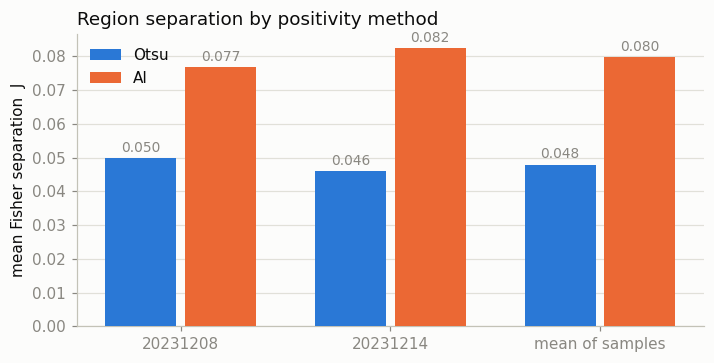

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
x = np.arange(len(summary))
w = 0.38
for i, m in enumerate(METHODS):
    bars = ax.bar(x + (i - 0.5) * w, summary[m], width=w - 0.04,
                  color=colour[i], label=m, zorder=3)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9, color=MUTED)
ax.set_xticks(x, summary.index)
ax.set_ylabel("mean Fisher separation  J")
ax.set_title("Region separation by positivity method", loc="left")
ax.yaxis.grid(True, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Every case

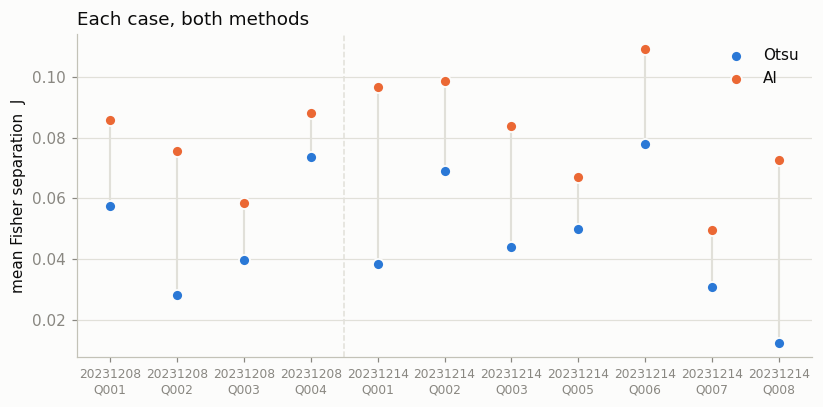

In [15]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
tick_labels = [f"{s}\n{c}" for s, c in per_case.index]
x = np.arange(len(per_case))
for xi, (_, row) in zip(x, per_case.iterrows()):
    ax.plot([xi, xi], [row[METHODS[0]], row[METHODS[1]]], color=GRID, lw=1.4, zorder=2)
for i, m in enumerate(METHODS):
    ax.scatter(x, per_case[m], s=52, color=colour[i], label=m, zorder=3,
               edgecolor="#fcfcfb", linewidth=1.2)

for i in range(1, len(per_case)):
    if per_case.index[i][0] != per_case.index[i - 1][0]:
        ax.axvline(i - 0.5, color=GRID, lw=1, ls="--")

ax.set_xticks(x, tick_labels, fontsize=8)
ax.set_ylabel("mean Fisher separation  J")
ax.set_title("Each case, both methods", loc="left")
ax.yaxis.grid(True, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Per cell type, per sample

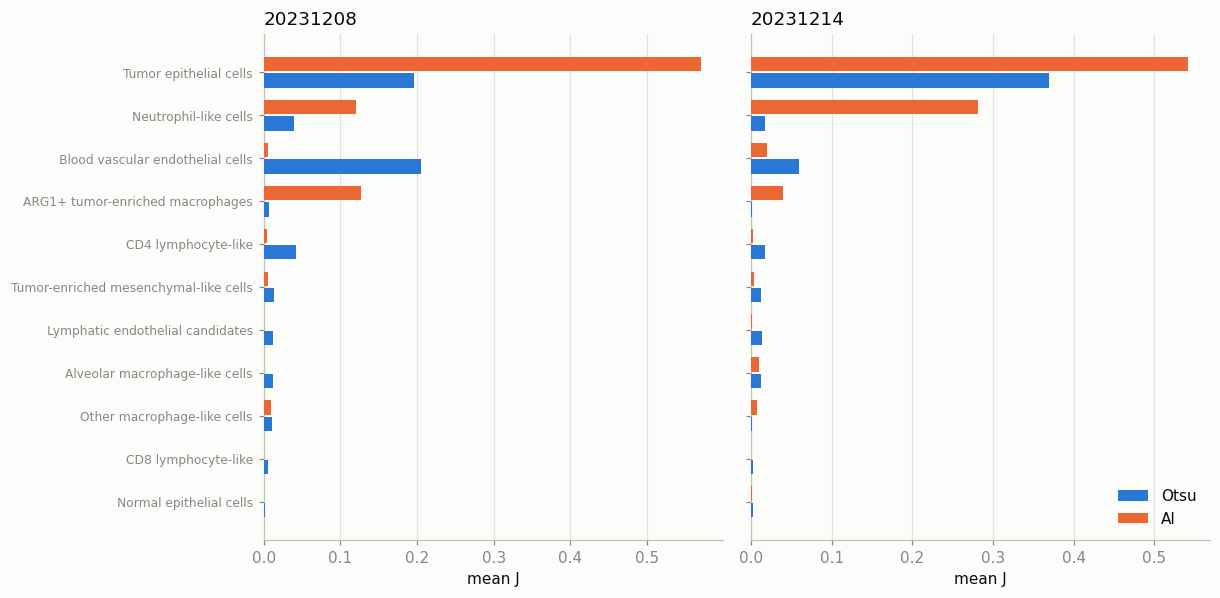

In [16]:
order = (per_type.groupby("cell_type").max().max(axis=1)
         .reindex(scored).sort_values().index.tolist())

fig, axes = plt.subplots(1, len(SAMPLES), sharey=True,
                         figsize=(5.6 * len(SAMPLES), 0.34 * len(order) + 1.8))
axes = np.atleast_1d(axes)
for ax, sample in zip(axes, SAMPLES):
    tab = per_type.loc[sample].reindex(order)
    y = np.arange(len(order))
    for i, m in enumerate(METHODS):
        ax.barh(y + (i - 0.5) * 0.38, tab[m].fillna(0), height=0.34,
                color=colour[i], label=m, zorder=3)
    ax.set_yticks(y, order, fontsize=8)
    ax.set_xlabel("mean J")
    ax.set_title(sample, loc="left")
    ax.xaxis.grid(True, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
axes[-1].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

### Odds ratio per cell type

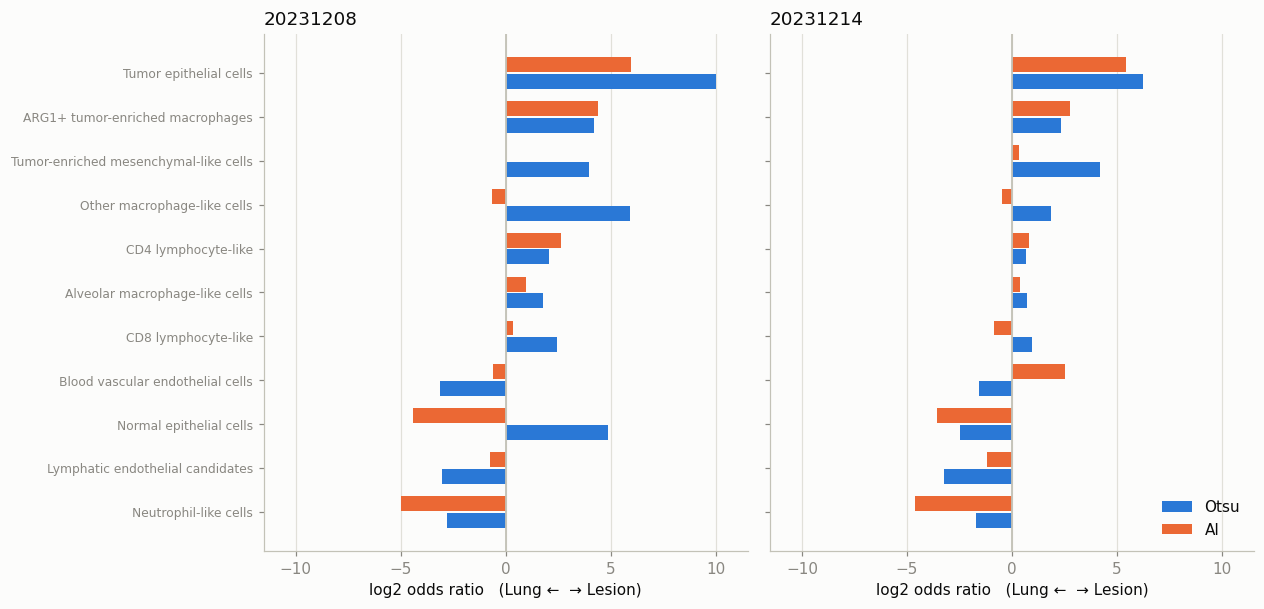

In [17]:
# log2 so Lesion- and Lung-enriched types are symmetric about 0.
lo = (pooled[pooled["cell_type"].isin(scored)]
      .pivot_table(index=["sample", "cell_type"], columns="method",
                   values="log2 OR", dropna=False)
      .reindex(columns=METHODS))
or_order = (lo.groupby("cell_type").mean().mean(axis=1)
            .reindex(scored).sort_values().index.tolist())

fig, axes = plt.subplots(1, len(SAMPLES), sharey=True,
                         figsize=(5.8 * len(SAMPLES), 0.34 * len(or_order) + 1.9))
axes = np.atleast_1d(axes)
finite = lo.to_numpy(dtype=float)
finite = finite[np.isfinite(finite)]
lim = float(np.max(np.abs(finite))) * 1.15 if finite.size else 1.0

for ax, sample in zip(axes, SAMPLES):
    tab = lo.loc[sample].reindex(or_order)
    y = np.arange(len(or_order))
    for i, m in enumerate(METHODS):
        vals = tab[m].to_numpy(dtype=float)
        ax.barh(y + (i - 0.5) * 0.38, np.nan_to_num(vals, nan=0.0, posinf=lim,
                                                    neginf=-lim),
                height=0.34, color=colour[i], label=m, zorder=3)
        # mark the ones that ran off the scale because a region had no cells
        for yi, v in zip(y + (i - 0.5) * 0.38, vals):
            if not np.isfinite(v):
                ax.text(lim * 0.98 if v > 0 else -lim * 0.98, yi,
                        "inf" if v > 0 else ("0" if v < 0 else "n/a"),
                        va="center", ha="right" if v > 0 else "left",
                        fontsize=7, color=MUTED)
    ax.axvline(0, color="#c3c2b7", lw=1.2, zorder=4)
    ax.set_yticks(y, or_order, fontsize=8)
    ax.set_xlim(-lim, lim)
    ax.set_xlabel(f"log2 odds ratio   ({other_region} ←  → {POSITIVE_REGION})")
    ax.set_title(sample, loc="left")
    ax.xaxis.grid(True, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
axes[-1].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## Saving the numbers

In [18]:
out_dir = Path.cwd() / "region_celltype_results"
out_dir.mkdir(exist_ok=True)

loaded.to_csv(out_dir / "projects_loaded.csv", index=False)
counts_long.to_csv(out_dir / "counts_per_case.csv", index=False)
sep.drop(columns=["J_finite"]).to_csv(out_dir / "separation_per_case.csv", index=False)
per_type.to_csv(out_dir / "separation_per_type_per_sample.csv")
per_case.to_csv(out_dir / "separation_per_case_mean.csv")
summary.to_csv(out_dir / "separation_summary.csv")
headline.to_csv(out_dir / "separation_headline.csv")
direction.to_csv(out_dir / "tumour_direction.csv")
pooled.to_csv(out_dir / "odds_ratio_pooled.csv", index=False)
odds_summary.to_csv(out_dir / "odds_ratio_summary.csv")
per_case_odds.to_csv(out_dir / "odds_ratio_per_case.csv", index=False)

print(f"wrote 11 CSVs to {out_dir}")

wrote 11 CSVs to C:\opal-studio\notebooks\region_celltype_results
